<a href="https://colab.research.google.com/github/chenuli949/AI-movie-review-analysis/blob/Chenuli/04_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!git clone https://github.com/chenuli949/AI-movie-review-analysis.git

Cloning into 'AI-movie-review-analysis'...
remote: Enumerating objects: 22, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 22 (delta 2), reused 4 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (22/22), 25.39 MiB | 16.96 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [3]:
%cd AI-movie-review-analysis

/content/AI-movie-review-analysis


# LSTM for IMDb Movie Review Sentiment Analysis

This notebook implements an LSTM-based deep learning model for binary sentiment classification of IMDb movie reviews.

In [4]:
import os
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.layers import TextVectorization

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed:", SEED)

Random seed: 42


In [6]:
DATA_PATH = "data/processed_imdb_reviews.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset shape: (50000, 2)

Columns:
['clean_review', 'label']


,clean_review,label
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. The filming tec...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [7]:
#Verify the processed dataset
print("Number of rows:", len(df))
print("Missing values:")
print(df.isnull().sum())

print("\nLabel distribution:")
print(df["label"].value_counts())

print("\nLabel values:")
print(sorted(df["label"].unique()))

Number of rows: 50000
Missing values:
clean_review    0
label           0
dtype: int64

Label distribution:
label
1    25000
0    25000
Name: count, dtype: int64

Label values:
[np.int64(0), np.int64(1)]


In [8]:
#Load predefined split indices
train_idx = np.load("data/train_indices.npy")
val_idx = np.load("data/validation_indices.npy")
test_idx = np.load("data/test_indices.npy")

print("Training indices:", len(train_idx))
print("Validation indices:", len(val_idx))
print("Test indices:", len(test_idx))

Training indices: 40000
Validation indices: 5000
Test indices: 5000


In [9]:
#Verify Indices
print("Total samples:", len(df))
print("Total split samples:", len(train_idx) + len(val_idx) + len(test_idx))

print("\nUnique indices:", len(
    np.unique(np.concatenate([train_idx, val_idx, test_idx]))
))

Total samples: 50000
Total split samples: 50000

Unique indices: 50000


In [10]:
#Create 3 datasets
X = df["clean_review"].values
y = df["label"].values

X_train = X[train_idx]
y_train = y[train_idx]

X_val = X[val_idx]
y_val = y[val_idx]

X_test = X[test_idx]
y_test = y[test_idx]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (40000,)
y_train: (40000,)
X_val: (5000,)
y_val: (5000,)
X_test: (5000,)
y_test: (5000,)


In [11]:
#Check Class Distribution
print("Training distribution:")
print(pd.Series(y_train).value_counts())

print("\nValidation distribution:")
print(pd.Series(y_val).value_counts())

print("\nTest distribution:")
print(pd.Series(y_test).value_counts())

Training distribution:
1    20000
0    20000
Name: count, dtype: int64

Validation distribution:
0    2500
1    2500
Name: count, dtype: int64

Test distribution:
0    2500
1    2500
Name: count, dtype: int64


In [12]:
VOCAB_SIZE = 20000
MAX_SEQUENCE_LENGTH = 300
EMBEDDING_DIM = 128

print("Vocabulary size:", VOCAB_SIZE)
print("Maximum sequence length:", MAX_SEQUENCE_LENGTH)
print("Embedding dimension:", EMBEDDING_DIM)

Vocabulary size: 20000
Maximum sequence length: 300
Embedding dimension: 128


In [13]:
#Create TextVectorization layer
vectorizer = TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=MAX_SEQUENCE_LENGTH
)

In [14]:
#Adapt the vectorizer(Learn the vocabulary from training data only)
vectorizer.adapt(X_train)

print("Vocabulary size:", len(vectorizer.get_vocabulary()))

Vocabulary size: 20000


In [15]:
#Check voabulary
vocabulary = vectorizer.get_vocabulary()

print("Actual vocabulary size:", len(vocabulary))
print("\nFirst 20 tokens:")
print(vocabulary[:20])

Actual vocabulary size: 20000

First 20 tokens:
['', '[UNK]', np.str_('the'), np.str_('and'), np.str_('a'), np.str_('of'), np.str_('to'), np.str_('is'), np.str_('in'), np.str_('it'), np.str_('i'), np.str_('this'), np.str_('that'), np.str_('was'), np.str_('as'), np.str_('for'), np.str_('with'), np.str_('movie'), np.str_('but'), np.str_('film')]


In [16]:
#Test the vectorization
sample_text = np.array([
    "This movie was absolutely amazing and enjoyable."
])

vectorized_sample = vectorizer(sample_text)

print("Vectorized shape:", vectorized_sample.shape)
print(vectorized_sample.numpy())

Vectorized shape: (1, 300)
[[ 11  17  13 411 479   3 716   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0  

In [17]:
#Building the LSTM model
model = models.Sequential([
    layers.Input(shape=(), dtype=tf.string),

    vectorizer,

    layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    ),

    layers.LSTM(128),

    layers.Dropout(0.5),

    layers.Dense(64, activation="relu"),

    layers.Dense(1, activation="sigmoid")
])


In [18]:
#Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 300)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 300, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,699,905 (10.30 MB)

 Trainable params: 2,699,905 (10.30 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
#Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)
print("Model compiled successfully.")

Model compiled successfully.


In [20]:
#Setup Early Stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

print("Early stopping configured.")

Early stopping configured.


In [21]:
#Train the LSTM
EPOCHS = 10
BATCH_SIZE = 64

start_time = time.time()

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)

training_time = time.time() - start_time

print(f"\nTraining time: {training_time:.2f} seconds")

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.8141 - loss: 0.4123 - precision: 0.8263 - recall: 0.7954 - val_accuracy: 0.8716 - val_loss: 0.3172 - val_precision: 0.9181 - val_recall: 0.8160
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.9006 - loss: 0.2623 - precision: 0.8949 - recall: 0.9077 - val_accuracy: 0.8672 - val_loss: 0.3778 - val_precision: 0.8933 - val_recall: 0.8340
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.9342 - loss: 0.1820 - precision: 0.9325 - recall: 0.9362 - val_accuracy: 0.8796 - val_loss: 0.3281 - val_precision: 0.8576 - val_recall: 0.9104

Training time: 49.15 seconds


In [22]:
print("Training epochs completed:", len(history.history["loss"]))


Training epochs completed: 3


In [23]:
history_df = pd.DataFrame(history.history)

history_df

,accuracy,loss,precision,recall,val_accuracy,val_loss,val_precision,val_recall
0,0.814125,0.412329,0.826347,0.7954,0.8716,0.317157,0.918092,0.8160
1,0.900575,0.262284,0.894947,0.9077,0.8672,0.377802,0.893316,0.8340
2,0.934200,0.181962,0.932470,0.9362,0.8796,0.328135,0.857573,0.9104


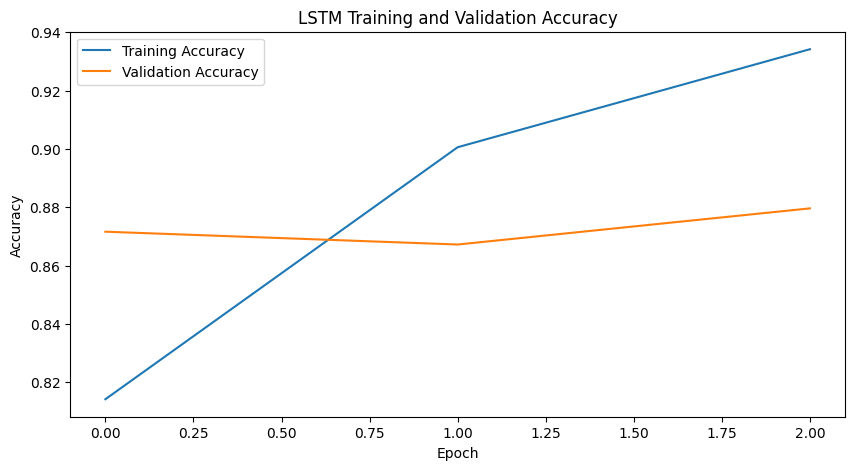

In [24]:
#Plot Accuracy
plt.figure(figsize=(10, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("LSTM Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

### Interpretation

The plot shows the training and validation accuracy of the LSTM model across the training epochs. Training accuracy increased from **81.41% in Epoch 1 to 93.42% in Epoch 3**, showing that the model continued to learn the training data. However, validation accuracy remained around **87–88%** and did not increase at the same rate.

This difference between training and validation accuracy suggests that the model began to **overfit** the training data. In other words, the model continued improving on data it had already seen, while its ability to generalize to unseen validation data improved only slightly.

The validation accuracy was highest at **87.96% in Epoch 3**, but the best validation loss occurred in **Epoch 1 (0.3172)**. Since early stopping was configured to monitor validation loss with a patience of 2 epochs, training stopped after three epochs. With `restore_best_weights=True`, the model restored the weights from the epoch with the lowest validation loss.


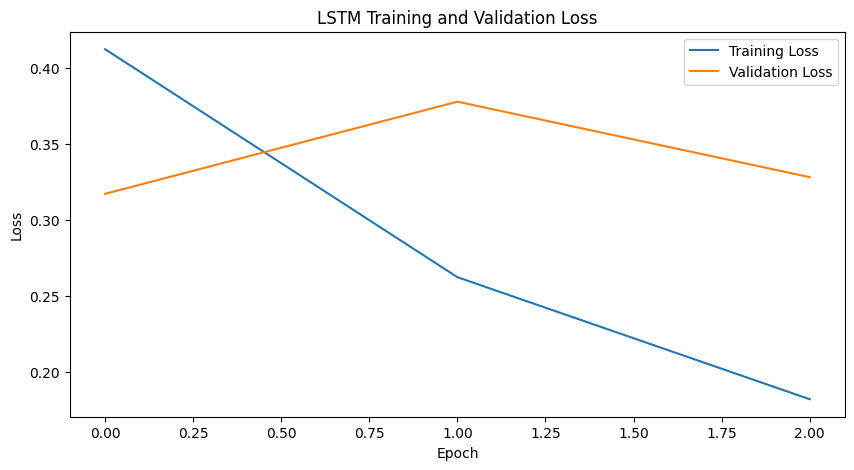

In [25]:
#Plot loss
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

### Interpretation

The plot shows the training and validation loss of the LSTM model across the training epochs. Training loss decreased consistently from **0.4123 in Epoch 1 to 0.2623 in Epoch 2 and 0.1820 in Epoch 3**, indicating that the model continued to improve its fit to the training data.

In contrast, validation loss was **0.3172 in Epoch 1**, increased to **0.3778 in Epoch 2**, and then decreased slightly to **0.3281 in Epoch 3**. The validation loss did not improve beyond the value achieved in Epoch 1.

The continuous decrease in training loss while validation loss became higher indicates that the model started to **overfit the training data**. This means the LSTM was learning the training examples increasingly well, but additional training did not consistently improve its performance on unseen validation data.

The early stopping mechanism monitored validation loss with a **patience of 2 epochs**. Since the validation loss did not improve after Epoch 1, training stopped after Epoch 3. Because `restore_best_weights=True` was used, the model restored the weights from **Epoch 1**, which had the lowest validation loss.


In [26]:
#Final test evaluation
test_results = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test results:")
print(test_results)

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8738 - loss: 0.3182 - precision: 0.9320 - recall: 0.8064
Test results:
[0.31818726658821106, 0.8737999796867371, 0.9320388436317444, 0.8064000010490417]


In [27]:
#Generate predictions on test set
y_prob = model.predict(X_test, verbose=1).ravel()

y_pred = (y_prob >= 0.5).astype(int)

print("First 10 probabilities:")
print(y_prob[:10])

print("\nFirst 10 predicted labels:")
print(y_pred[:10])

print("\nFirst 10 actual labels:")
print(y_test[:10])


157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
First 10 probabilities:
[0.0761847  0.67928433 0.25932673 0.07578319 0.02432397 0.05271376
 0.08717232 0.03564726 0.8230428  0.05719868]

First 10 predicted labels:
[0 1 0 0 0 0 0 0 1 0]

First 10 actual labels:
[0 1 1 0 0 0 0 0 1 0]


In [28]:
#Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("LSTM Test Results")
print("=" * 40)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

LSTM Test Results
Accuracy : 0.8738
Precision: 0.9320
Recall   : 0.8064
F1-score : 0.8647
ROC-AUC  : 0.9465


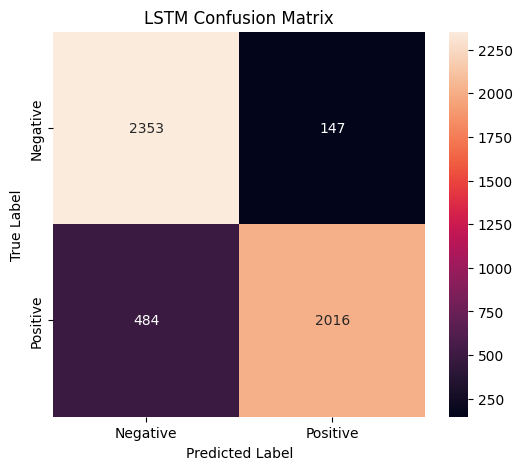

In [29]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

The model has relatively few false positives (147) but more false negatives (484).

In [30]:
#Classification report
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.83      0.94      0.88      2500
    Positive       0.93      0.81      0.86      2500

    accuracy                           0.87      5000
   macro avg       0.88      0.87      0.87      5000
weighted avg       0.88      0.87      0.87      5000



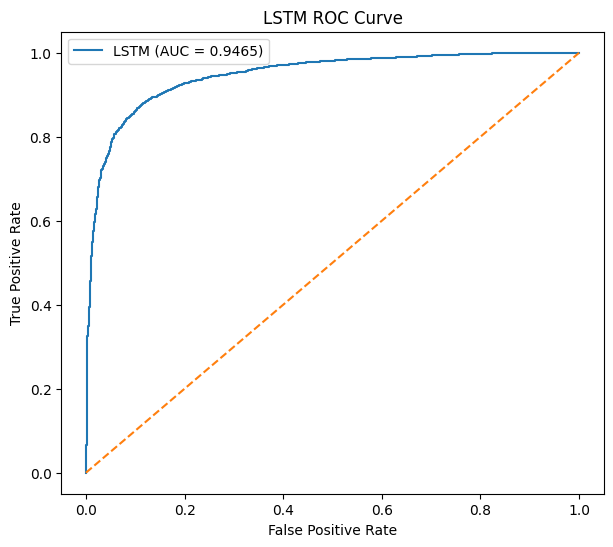

In [31]:
#ROC-AUC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"LSTM (AUC = {auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("LSTM ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

Interpretaion
The **Receiver Operating Characteristic (ROC) curve** illustrates the performance of the LSTM classification model across different classification thresholds. It plots the **True Positive Rate (TPR)** against the **False Positive Rate (FPR)**.

* **True Positive Rate (TPR):** Also known as recall or sensitivity, it represents the proportion of actual positive reviews that are correctly classified as positive.
* **False Positive Rate (FPR):** It represents the proportion of actual negative reviews that are incorrectly classified as positive.

For the LSTM model, the **Area Under the Curve (AUC) is 0.9465**. AUC summarizes the model's ability to distinguish between positive and negative reviews across different classification thresholds. An AUC closer to 1.0 indicates stronger class-discrimination ability, while an AUC of 0.5 represents performance equivalent to random classification.

The ROC curve shows the trade-off between TPR and FPR as the classification threshold changes. A curve closer to the **top-left corner** generally indicates stronger discrimination because it achieves a high TPR while maintaining a low FPR. The diagonal dashed line represents the performance of a random classifier, with an AUC of 0.5.

The LSTM curve lies substantially above the random-classifier line, with an **AUC of 0.9465**, indicating that the model has a strong ability to distinguish between positive and negative reviews across different decision thresholds. Importantly, the AUC should not be interpreted as 94.65% accuracy; it measures discrimination across thresholds rather than performance at the single 0.5 classification threshold.


In [32]:
#Create result folders
import os

os.makedirs("results/metrics", exist_ok=True)
os.makedirs("results/figures", exist_ok=True)
os.makedirs("models", exist_ok=True)

print("Result folders ready.")

Result folders ready.


In [33]:
#Save LSTM metrics
lstm_results = pd.DataFrame({
    "Model": ["LSTM"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1": [f1],
    "ROC_AUC": [auc],
    "Training_Time_Seconds": [training_time],
    "Parameters": [model.count_params()]
})

lstm_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Training_Time_Seconds,Parameters
0,LSTM,0.8738,0.932039,0.8064,0.864679,0.946491,49.150612,2699905


In [34]:
#Save LSTM metrics into csv
lstm_results.to_csv(
    "results/metrics/lstm_results.csv",
    index=False
)

print("LSTM results saved.")

LSTM results saved.


In [35]:
#Save model
model.save("models/lstm_imdb.keras")

print("LSTM model saved.")

LSTM model saved.


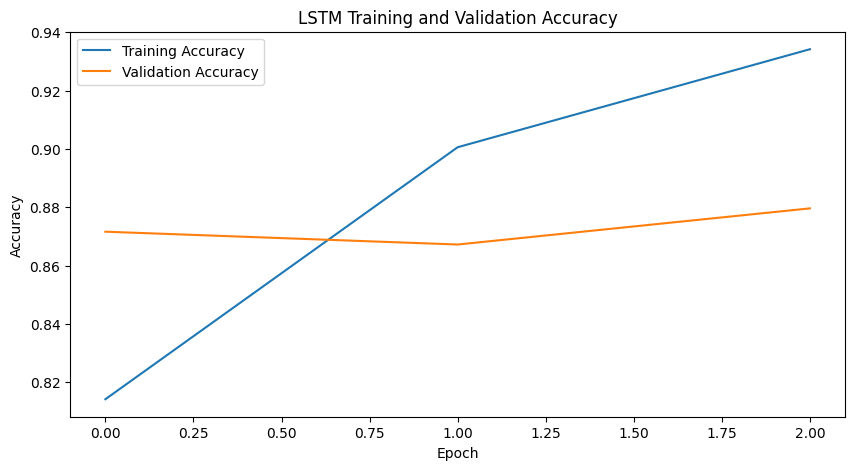

In [36]:
#Save accuracy graph
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("LSTM Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig(
    "results/figures/lstm_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

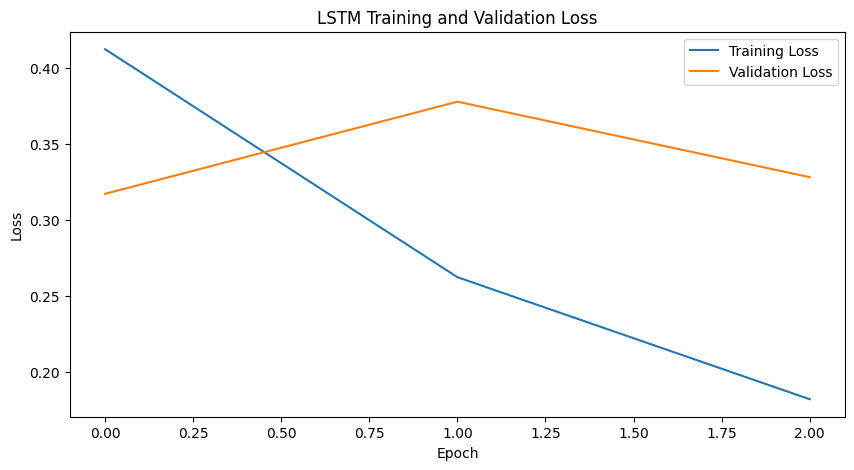

In [37]:
#Save the loss graph
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig(
    "results/figures/lstm_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

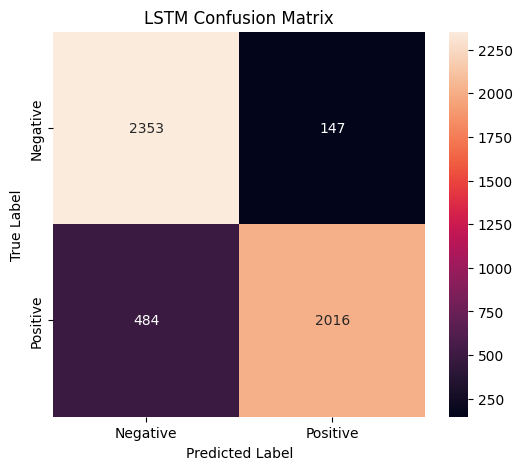

In [38]:
#Save confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.savefig(
    "results/figures/lstm_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

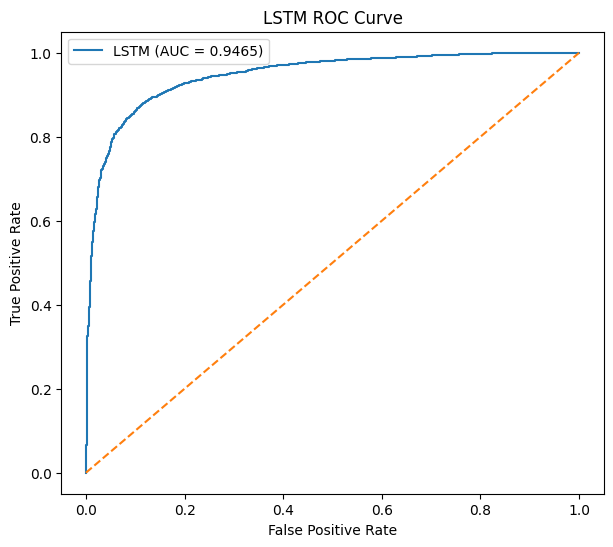

In [39]:
#Save ROC curve
plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"LSTM (AUC = {auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("LSTM ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.savefig(
    "results/figures/lstm_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Final Check

In [41]:
print("===== LSTM EXPERIMENT SUMMARY =====")

print(f"Training samples : {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples     : {len(X_test)}")

print(f"\nVocabulary size  : {VOCAB_SIZE}")
print(f"Sequence length  : {MAX_SEQUENCE_LENGTH}")
print(f"Embedding dim    : {EMBEDDING_DIM}")

print(f"\nAccuracy          : {accuracy:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"F1-score          : {f1:.4f}")
print(f"ROC-AUC           : {auc:.4f}")

print(f"\nTraining time     : {training_time:.2f} seconds")
print(f"Parameters        : {model.count_params()}")

===== LSTM EXPERIMENT SUMMARY =====
Training samples : 40000
Validation samples: 5000
Test samples     : 5000

Vocabulary size  : 20000
Sequence length  : 300
Embedding dim    : 128

Accuracy          : 0.8738
Precision         : 0.9320
Recall            : 0.8064
F1-score          : 0.8647
ROC-AUC           : 0.9465

Training time     : 49.15 seconds
Parameters        : 2699905
